# Analyse Rapide - DA_jab

**Objectif** : Explorer les données des catastrophes naturelles  
**Date** : 18 février 2026  
**Données** : dev.duckdb, odis.duckdb

## 1. Imports et Configuration

In [1]:
import pandas as pd
import duckdb
import matplotlib.pyplot as plt

In [6]:
#cmd pour verifier que duckdb est bien installé
# !duckdb --version et ls data\exploration\*.duckdb

# Configuration d'affichage pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 50)
pd.set_option("display.expand_frame_repr", False)

print("✅ Imports réussis !")

✅ Imports réussis !


## 2. Connexion aux Bases de Données

In [7]:
# Connexion à dev.duckdb
con = duckdb.connect(database="dev.duckdb", read_only=True)

# Attacher la base odis
con.sql("ATTACH 'odis.duckdb' AS odis;")

print("✅ Connexion établie !")

✅ Connexion établie !


## 3. Exploration Rapide : Lister les Tables

In [8]:
# Lister toutes les tables disponibles
tables = con.sql("SHOW TABLES").df()
print(f"📊 Nombre de tables disponibles : {len(tables)}")
tables

📊 Nombre de tables disponibles : 13


,name
0,azi_gaspar
1,catnat_gaspar
2,ccr_details
3,ccr_main_page
4,dicrim_gaspar
5,my_first_dbt_model
6,my_second_dbt_model
7,pprm_gaspar
8,pprn_gaspar
9,pprt_gaspar


## 4. Analyse : Catastrophes Naturelles par Année

In [11]:
# Évolution des catastrophes depuis 2000
evolution = con.sql("""
    SELECT 
        YEAR(CAST(dat_pub_jo AS DATE)) as annee,
        COUNT(*) as nb_catastrophes
    FROM catnat_gaspar
    WHERE CAST(dat_pub_jo AS DATE) >= '2000-01-01'
    GROUP BY YEAR(CAST(dat_pub_jo AS DATE))
    ORDER BY annee
""").df()

print(f"📈 Données de {evolution['annee'].min()} à {evolution['annee'].max()}")
evolution.tail(10)

📈 Données de 2000 à 2025


,annee,nb_catastrophes
16,2016,3237
17,2017,1633
18,2018,6493
19,2019,5173
20,2020,5240
21,2021,5098
22,2022,1457
23,2023,9379
24,2024,5379
25,2025,1301


## 5. Visualisation : Tendance des Catastrophes

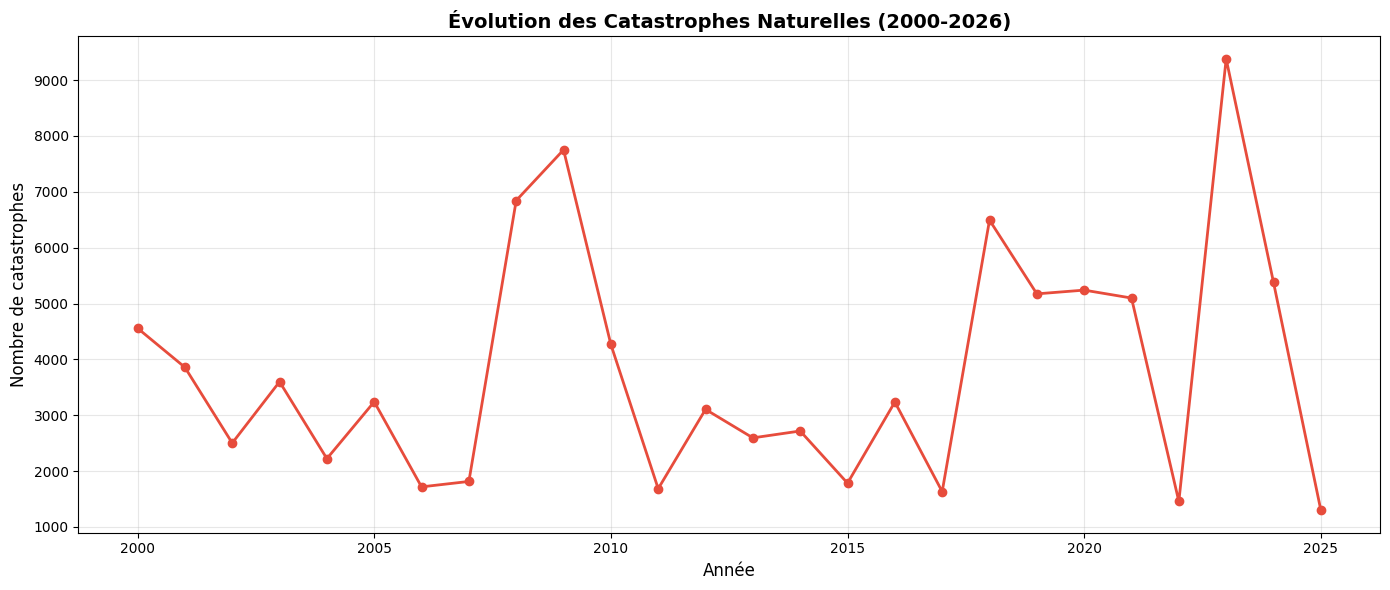

🔥 Total des catastrophes : 98,654


In [12]:
# Graphique de l'évolution
plt.figure(figsize=(14, 6))
plt.plot(evolution['annee'], evolution['nb_catastrophes'], marker='o', linewidth=2, color='#e74c3c')
plt.title('Évolution des Catastrophes Naturelles (2000-2026)', fontsize=14, fontweight='bold')
plt.xlabel('Année', fontsize=12)
plt.ylabel('Nombre de catastrophes', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"🔥 Total des catastrophes : {evolution['nb_catastrophes'].sum():,}")

## 6. Analyse : Types de Risques les Plus Fréquents

In [15]:
con.sql("DESCRIBE catnat_gaspar").df()

,column_name,column_type,null,key,default,extra
0,cod_nat_catnat,VARCHAR,YES,None,None,None
1,cod_commune,VARCHAR,YES,None,None,None
2,lib_commune,VARCHAR,YES,None,None,None
3,num_risque_jo,VARCHAR,YES,None,None,None
4,lib_risque_jo,VARCHAR,YES,None,None,None
5,dat_deb,VARCHAR,YES,None,None,None
6,dat_fin,VARCHAR,YES,None,None,None
7,dat_pub_arrete,VARCHAR,YES,None,None,None
8,dat_pub_jo,VARCHAR,YES,None,None,None
9,dat_maj,VARCHAR,YES,None,None,None


In [16]:
# Top 10 des types de risques
types_risques = con.sql("""
    SELECT 
        lib_risque_jo,
        COUNT(*) as occurrences,
        COUNT(DISTINCT cod_commune) as communes_touchees
    FROM catnat_gaspar
    WHERE CAST(dat_pub_jo AS DATE) >= '2010-01-01'
    GROUP BY lib_risque_jo
    ORDER BY occurrences DESC
    LIMIT 10
""").df()

types_risques

,lib_risque_jo,occurrences,communes_touchees
0,Inondations et/ou Coulées de Boue,28663,15743
1,Sécheresse,26662,12709
2,Mouvement de Terrain,3108,2466
3,Chocs Mécaniques liés à l'action des Vagues,1394,1098
4,Inondations Remontée Nappe,541,476
5,Secousse Sismique,99,99
6,Vents Cycloniques,44,44
7,Avalanche,31,24
8,Lave Torrentielle,2,2


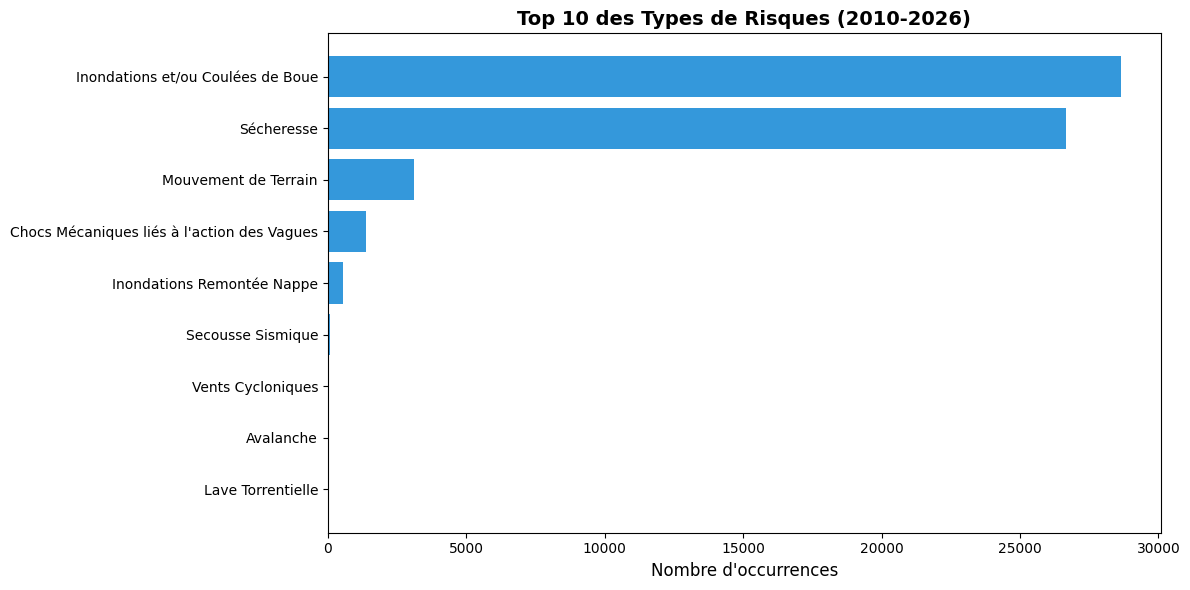

In [17]:
# Graphique en barres
plt.figure(figsize=(12, 6))
plt.barh(types_risques['lib_risque_jo'], types_risques['occurrences'], color='#3498db')
plt.xlabel('Nombre d\'occurrences', fontsize=12)
plt.title('Top 10 des Types de Risques (2010-2026)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Analyse : Top Communes les Plus Touchées

In [18]:
# Top 15 communes
top_communes = con.sql("""
    SELECT 
        lib_commune,
        COUNT(*) as nb_catastrophes,
        COUNT(DISTINCT lib_risque_jo) as nb_types_risques
    FROM catnat_gaspar
    WHERE CAST(dat_pub_jo AS DATE) >= '2015-01-01'
    GROUP BY lib_commune
    ORDER BY nb_catastrophes DESC
    LIMIT 15
""").df()

top_communes

,lib_commune,nb_catastrophes,nb_types_risques
0,La Verdière,32,2
1,Nice,31,4
2,La Trinité,26,3
3,Saint-Louis,24,4
4,Sainte-Marie,24,4
5,Le Broc,22,3
6,Montréal,21,2
7,Cagnes-sur-Mer,20,4
8,Vence,19,3
9,Vaux,19,2


## 8. Statistiques Globales

In [19]:
# Résumé global
stats = con.sql("""
    SELECT 
        COUNT(*) as total_catastrophes,
        COUNT(DISTINCT cod_commune) as communes_touchees,
        COUNT(DISTINCT lib_risque_jo) as types_risques_differents,
        MIN(dat_pub_jo) as premiere_catastrophe,
        MAX(dat_pub_jo) as derniere_catastrophe
    FROM catnat_gaspar
""").df()

print("\n📊 STATISTIQUES GLOBALES")
print("=" * 60)
for col in stats.columns:
    print(f"{col:30} : {stats[col].iloc[0]}")
print("=" * 60)


📊 STATISTIQUES GLOBALES
total_catastrophes             : 260799
communes_touchees              : 34704
types_risques_differents       : 21
premiere_catastrophe           : 1982-09-30 00:00:00
derniere_catastrophe           : 2025-10-23 02:00:00


## 9. Fermer la Connexion

In [ ]:
con.close()
print("✅ Connexion fermée")

---

## 🎯 Prochaines Étapes

- [ ] Analyser la corrélation entre population et catastrophes
- [ ] Explorer les données CCR (indemnisations)
- [ ] Croiser avec les données de chômage
- [ ] Créer une carte géographique des risques